## Data reduction

In [1]:
!ls -la /net/vega/data/users/observatory/images/260429/STL-6303E/i/

total 3444032
drwxrwsr-t 2 telescoop observer    28672 Apr 30 05:47  .
drwxrwsr-t 4 telescoop observer     4096 Apr 29 20:03  ..
-rw-r--r-- 1 telescoop observer 12591360 Apr 29 20:16  260429_LI_.00000001.HIP_44356.BIAS.FIT
-rw-r--r-- 1 telescoop observer 12591360 Apr 29 20:18  260429_LI_.00000002.HIP_44356.BIAS.FIT
-rw-r--r-- 1 telescoop observer 12591360 Apr 29 20:18  260429_LI_.00000003.HIP_44356.BIAS.FIT
-rw-r--r-- 1 telescoop observer 12591360 Apr 29 20:19  260429_LI_.00000004.HIP_44356.BIAS.FIT
-rw-r--r-- 1 telescoop observer 12591360 Apr 29 20:19  260429_LI_.00000005.HIP_44356.BIAS.FIT
-rw-r--r-- 1 telescoop observer 12591360 Apr 29 20:20  260429_LI_.00000006.HIP_44356.BIAS.FIT
-rw-r--r-- 1 telescoop observer 12591360 Apr 29 20:20  260429_LI_.00000007.HIP_44356.BIAS.FIT
-rw-r--r-- 1 telescoop observer 12591360 Apr 29 20:20  260429_LI_.00000008.HIP_44356.BIAS.FIT
-rw-r--r-- 1 telescoop observer 12591360 Apr 29 20:21  260429_LI_.00000009.HIP_44356.BIAS.FIT
-rw-r--r-- 1 telescoop ob

In [1]:
import os
import shutil
import glob
# paths
src = '/net/vega/data/users/observatory/images/260429/STL-6303E/i/'
dst = '/Users/users/lburgos/DATASERVER'

if not os.path.exists(dst):
    os.makedirs(dst)

files = glob.glob(os.path.join(src, '*.FIT'))

# fallback if extensions are lowercase
if not files:
    files = [os.path.join(src, f) for f in os.listdir(src) if f.lower().endswith(('.fit', '.fits'))]

print(f"found {len(files)} files, copying...")

for p in files:
    name = os.path.basename(p)
    
    # skip that weird 'Select Folder' file
    if "Select Folder" in name:
        continue
        
    shutil.copy(p, os.path.join(dst, name))

print("done.")
print(os.listdir(dst)[:5])

found 280 files, copying...
done.
['260429_LI_.00000146.23h24m53.3s_61d34m35sN.FIT', '260429_LI_.00000158.23h24m54.3s_61d34m35sN.FIT', '260429_LI_.00000023.13h30m33.1s_47d14m02sN.FLAT.FIT', '260429_LI_.00000281.00h05m27.7s_40d51m08sN.FLAT.FIT', '260429_LI_.00000198.23h24m53.3s_61d34m35sN.GREEN.FIT']


In [2]:
import os
import re
import pandas as pd
from astropy.io import fits

dst = '/Users/users/lburgos/DATASERVER'
data = []

for f in sorted(os.listdir(dst)):
    if f.lower().endswith(('.fit', '.fits')):
        
        match = re.search(r'\.(\d{8})\.', f)
        if match:
            num = int(match.group(1))
            if num < 145:
                continue
        else:
            continue
            
        full_path = os.path.join(dst, f)
        try:
            with fits.open(full_path) as hdul:
                hdr = hdul[0].header
                if (num > 256) and (num < 267):
                    hdr["IMAGETYP"] = "Dark Frame"
                data.append({
                    'filename': f,
                    'object': hdr.get('OBJECT', 'N/A'),
                    'type': hdr.get('IMAGETYP', 'N/A'),
                    'exptime': hdr.get('EXPTIME', 'N/A'),
                    'filter': hdr.get('FILTER', 'N/A')
                })
        except Exception as e:
            print(f"err on {f}: {e}")

df = pd.DataFrame(data)

# extract file number to drop duplicates
df['tmp_num'] = df['filename'].str.extract(r'\.(\d{8})\.')
df = df.drop_duplicates(subset=['tmp_num']).drop(columns=['tmp_num'])

pd.set_option('display.max_rows', None)

print(f"done. unique rows: {len(df)}")
display(df)

done. unique rows: 136


,filename,object,type,exptime,filter
0,260429_LI_.00000145.23h24m52.3s_61d34m35sN.FIT,N/A,Light Frame,5.0,V
1,260429_LI_.00000146.23h24m53.3s_61d34m35sN.FIT,N/A,Light Frame,5.0,V
2,260429_LI_.00000148.23h24m53.3s_61d34m35sN.FIT,N/A,Light Frame,5.0,B
3,260429_LI_.00000149.23h24m54.3s_61d34m35sN.FIT,N/A,Light Frame,5.0,B
4,260429_LI_.00000150.23h24m53.3s_61d34m35sN.FIT,N/A,Light Frame,5.0,B
5,260429_LI_.00000151.23h24m53.3s_61d34m35sN.FIT,N/A,Light Frame,5.0,V
6,260429_LI_.00000152.23h24m54.3s_61d34m35sN.FIT,N/A,Light Frame,5.0,V
7,260429_LI_.00000153.23h24m52.3s_61d34m35sN.FIT,N/A,Light Frame,5.0,V
8,260429_LI_.00000154.23h24m53.3s_61d34m35sN.FIT,N/A,Light Frame,5.0,V
9,260429_LI_.00000155.23h24m53.3s_61d34m35sN.FIT,N/A,Light Frame,5.0,B


loading bias frames...
master bias done using 13 frames.


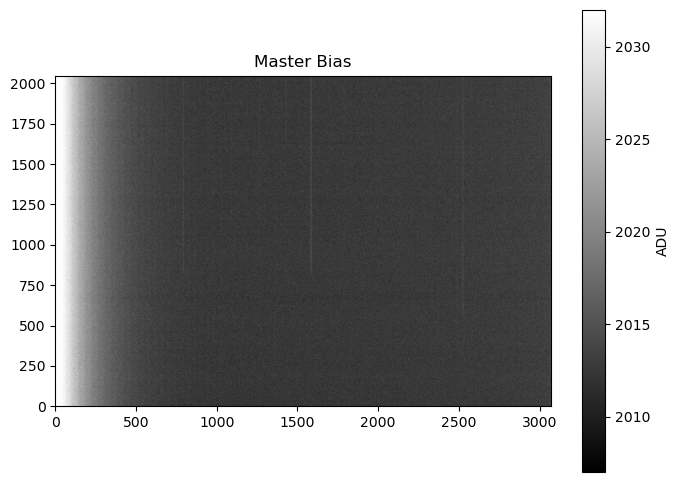

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

bias_frames = []

print("loading bias frames...")
for idx, row in df.iterrows():
    # check both header type and filename for 'bias'
    if 'BIAS' in str(row['type']).upper() or 'BIAS' in str(row['filename']).upper():
        path = os.path.join(dst, row['filename'])
        try:
            with fits.open(path) as hdul:
                bias_frames.append(hdul[0].data)
        except Exception as e:
            print(f"err loading {row['filename']}: {e}")

# combine to master if we found any
if bias_frames:
    # median combine to kick out cosmic rays / alpha hits
    master_bias = np.median(bias_frames, axis=0)
    print(f"master bias done using {len(bias_frames)} frames.")
    
    # plot with 2-98 percentile scaling to see structures
    plt.figure(figsize=(8, 6))
    plt.imshow(master_bias, cmap='gray', origin='lower', 
               vmin=np.percentile(master_bias, 2), vmax=np.percentile(master_bias, 98))
    plt.colorbar(label='ADU')
    plt.title('Master Bias')
    plt.show()
else:
    print("no bias frames found. check df filtering.")

loading dark frames...
master dark done using 10 frames.


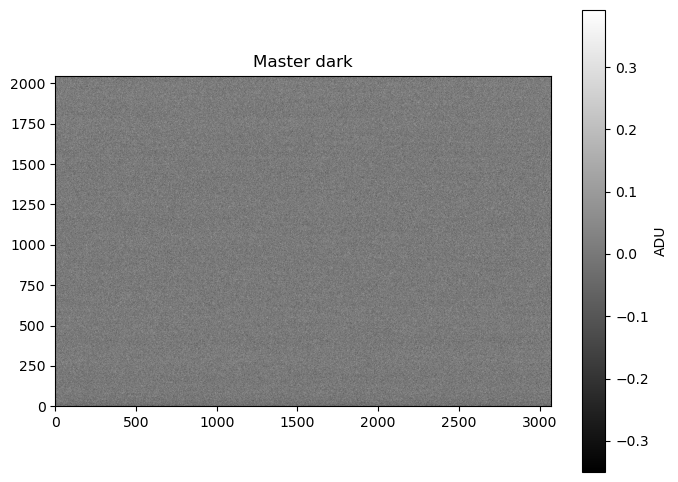

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

dark_frames = []
exposure_time = []
separated_darks = []

print("loading dark frames...")
for idx, row in df.iterrows():
    # check both header type and filename for 'dark'
    if 'DARK' in str(row['type']).upper() or 'DARK' in str(row['filename']).upper():
        path = os.path.join(dst, row['filename'])
        try:
            with fits.open(path) as hdul:
                dark_frames.append(hdul[0].data)
                exposure_time.append(hdul[0].header["EXPTIME"])
        except Exception as e:
            print(f"err loading {row['filename']}: {e}")

            
if dark_frames:
    for idx, i in enumerate(dark_frames):
        separated_darks.append((i - master_bias)/exposure_time[idx])
    master_dark = np.median(separated_darks, axis=0)
    print(f"master dark done using {len(dark_frames)} frames.")
    
    # plot with 2-98 percentile scaling to see structures
    plt.figure(figsize=(8, 6))
    plt.imshow(master_dark, cmap='gray', origin='lower', 
               vmin=np.percentile(master_dark, 2), vmax=np.percentile(master_dark, 98))
    plt.colorbar(label='ADU')
    plt.title('Master dark')
    plt.show()

found filters: ['V' 'B']

processing filter: V


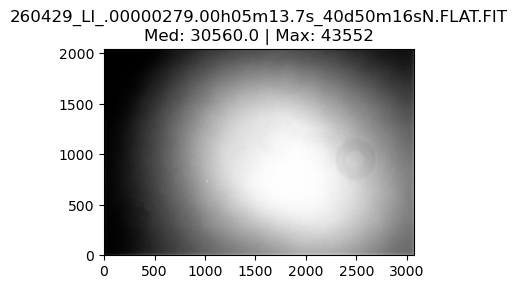

err on 260429_LI_.00000279.00h05m13.7s_40d50m16sN.FLAT.FIT: name 'master_dark' is not defined


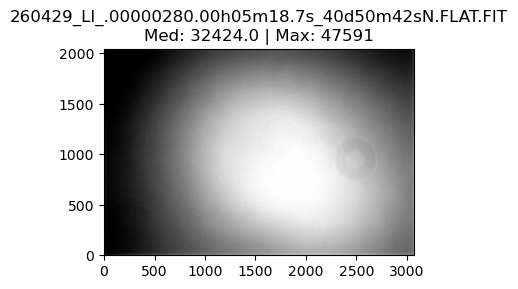

err on 260429_LI_.00000280.00h05m18.7s_40d50m42sN.FLAT.FIT: name 'master_dark' is not defined


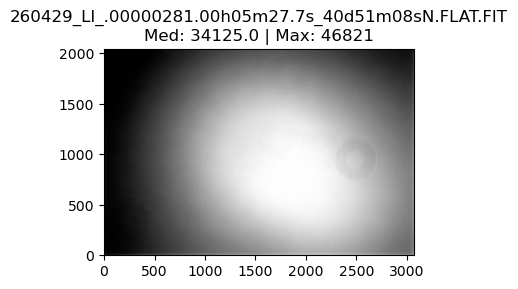

err on 260429_LI_.00000281.00h05m27.7s_40d51m08sN.FLAT.FIT: name 'master_dark' is not defined

processing filter: B


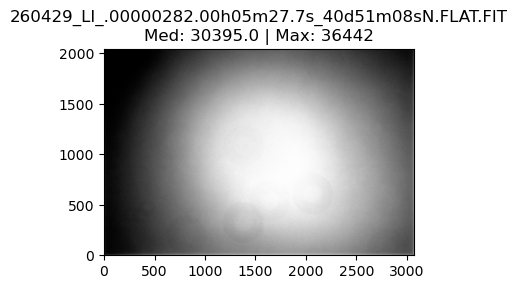

err on 260429_LI_.00000282.00h05m27.7s_40d51m08sN.FLAT.FIT: name 'master_dark' is not defined


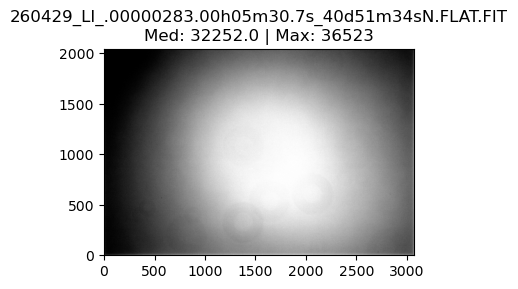

err on 260429_LI_.00000283.00h05m30.7s_40d51m34sN.FLAT.FIT: name 'master_dark' is not defined


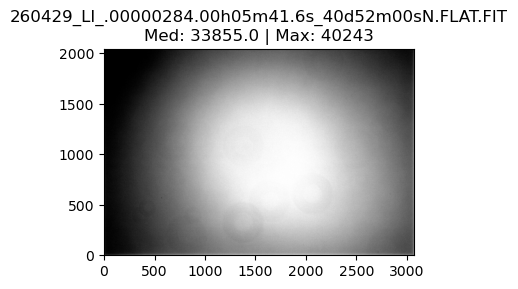

err on 260429_LI_.00000284.00h05m41.6s_40d52m00sN.FLAT.FIT: name 'master_dark' is not defined


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits

# filter flats from main df
flat_df = df[
    (df['filename'].str.contains('FLAT', case=False)) | 
    (df['type'].str.contains('Flat', case=False))
].copy()

# fix missing filters by checking filename strings
for idx, row in flat_df.iterrows():
    if row['filter'] == 'N/A' or pd.isna(row['filter']):
        fname = row['filename'].upper()
        if 'RED' in fname or '_R_' in fname: flat_df.at[idx, 'filter'] = 'R'
        elif 'GREEN' in fname or '_G_' in fname: flat_df.at[idx, 'filter'] = 'G'
        elif 'BLUE' in fname or '_B_' in fname: flat_df.at[idx, 'filter'] = 'B'
        elif 'HA' in fname or 'H_ALPHA' in fname: flat_df.at[idx, 'filter'] = 'H_alpha'
        elif 'LUM' in fname: flat_df.at[idx, 'filter'] = 'Lum'

filters = flat_df['filter'].unique()
print(f"found filters: {filters}")

master_flats = {}

for filt in filters:
    if filt == 'N/A':
        continue
    print(f"\nprocessing filter: {filt}")
    frames = []
    
    filter_df = flat_df[flat_df['filter'] == filt]
    
    for idx, row in filter_df.iterrows():
        path = os.path.join(dst, row['filename'])
        try:
            with fits.open(path) as hdul:
                img_data = hdul[0].data
                exptime = hdul[0].header["EXPTIME"]
                med = np.median(img_data)
                maximum = np.max(img_data)
                
                # quick visual check
                plt.figure(figsize=(4, 3))
                plt.imshow(img_data, cmap='gray', origin='lower', 
                           vmin=np.percentile(img_data, 5), vmax=np.percentile(img_data, 95))
                plt.title(f"{row['filename']}\nMed: {med:.1f} | Max: {maximum}")
                plt.show()
                
                # skip saturated frames (ccd non-linear zone)
                if maximum > 62000:
                    print(f"skipping {row['filename']} -> saturated (max={maximum})")
                    continue
                # skip empty/underexposed frames
                if med < 800:
                    print(f"skipping {row['filename']} -> empty frame (median={med})")
                    continue
                    
                # subtract bias and dark and normalize to 1.0
                bias_sub = img_data - master_bias - (master_dark * exptime)
                norm = bias_sub / np.median(bias_sub)
                frames.append(norm)
                
        except Exception as e:
            print(f"err on {row['filename']}: {e}")
            
    if frames:
        # median combine to get rid of dust/artifacts
        master_flats[filt] = np.median(frames, axis=0)
        print(f"master flat done for filter: {filt}")
        
        # plot normalized flat (should be around 1.0)
        plt.figure(figsize=(6, 5))
        plt.imshow(master_flats[filt], cmap='gray', origin='lower', vmin=0.8, vmax=1.2)
        plt.colorbar()
        plt.title(f'Master Flat - Filter {filt}')
        plt.show()

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

print("starting science frame reduction...")

# filter for actual science targets (kick out calibration files)
science_df = df[
    (~df['filename'].str.contains('BIAS|DARK|FLAT|Select|Mouse', case=False)) & 
    (~df['type'].str.contains('Bias|Flat|Dark', case=False))
]

for idx, row in science_df.iterrows():
    f_name = row['filename']
    obj = row['object']
    filt = row['filter']
    
    path = os.path.join(dst, f_name)
    
    # match master flat with current filter
    flat_frame = None
    for k in master_flats.keys():
        if str(k).upper() in str(filt).upper() or str(filt).upper() in str(k).upper():
            flat_frame = master_flats[k]
            break
            
    if flat_frame is None:
        print(f"skipping {f_name}: no master flat found for filter '{filt}'")
        continue
        
    try:
        with fits.open(path) as hdul:
            raw_data = hdul[0].data
            hdr = hdul[0].header
            
            # standard reduction formula: (raw - bias) / flat
            reduced = (raw_data - master_bias) / flat_frame
            
            out_name = "reduced_" + f_name
            out_path = os.path.join(dst, out_name)
            
            # save new fits with original header
            hdu = fits.PrimaryHDU(reduced, header=hdr)
            hdu.writeto(out_path, overwrite=True)
            
            print(f"reduced: {out_name} ({obj} | filter: {filt})")
            
            # plot with 2-98 scaling to check image quality
            plt.figure(figsize=(10, 8))
            vmin = np.percentile(reduced, 2)
            vmax = np.percentile(reduced, 98)
            
            plt.imshow(reduced, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
            plt.colorbar(label='intensity')
            plt.title(f"Reduced: {obj} | Filter: {filt} ({f_name})")
            plt.show()
            
    except Exception as e:
        print(f"err on reducing {f_name}: {e}")

print("all frames processed. done.")

starting science frame reduction...
skipping 260429_LI_.00000145.23h24m52.3s_61d34m35sN.FIT: no master flat found for filter 'V'
skipping 260429_LI_.00000146.23h24m53.3s_61d34m35sN.FIT: no master flat found for filter 'V'
skipping 260429_LI_.00000148.23h24m53.3s_61d34m35sN.FIT: no master flat found for filter 'B'
skipping 260429_LI_.00000149.23h24m54.3s_61d34m35sN.FIT: no master flat found for filter 'B'
skipping 260429_LI_.00000150.23h24m53.3s_61d34m35sN.FIT: no master flat found for filter 'B'
skipping 260429_LI_.00000151.23h24m53.3s_61d34m35sN.FIT: no master flat found for filter 'V'
skipping 260429_LI_.00000152.23h24m54.3s_61d34m35sN.FIT: no master flat found for filter 'V'
skipping 260429_LI_.00000153.23h24m52.3s_61d34m35sN.FIT: no master flat found for filter 'V'
skipping 260429_LI_.00000154.23h24m53.3s_61d34m35sN.FIT: no master flat found for filter 'V'
skipping 260429_LI_.00000155.23h24m53.3s_61d34m35sN.FIT: no master flat found for filter 'B'
skipping 260429_LI_.00000156.23h24

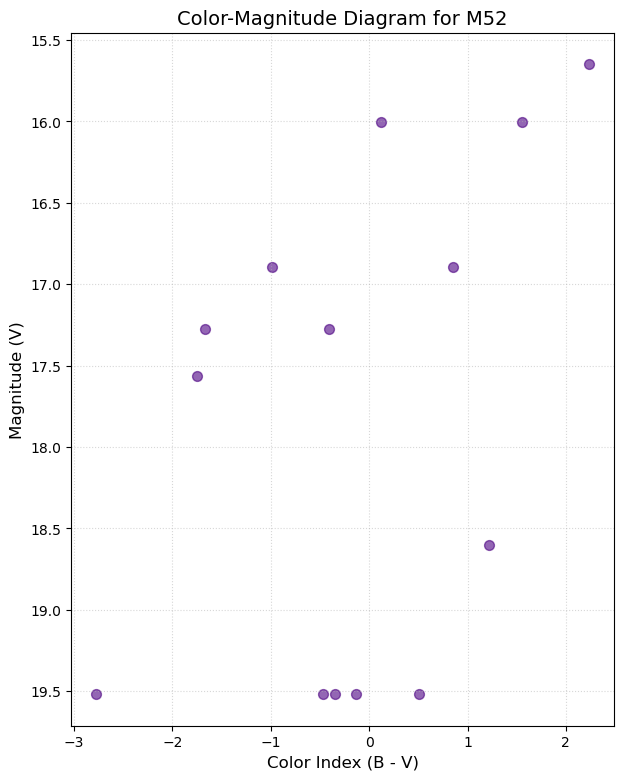

In [14]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture, aperture_photometry
from scipy.spatial import KDTree

#Just change the directory to yours if you wanna run this
output_directory = '/Users/users/lburgos/DATASERVER'

images_B = []
images_V = []

# 2. Automatically locate and load the calibrated files
search_pattern = os.path.join(output_directory, "*.FIT*") 
calibrated_files = glob.glob(search_pattern)

for file_path in calibrated_files:
    try:
        with fits.open(file_path) as hdul:
            hdr = hdul[0].header
            data = hdul[0].data.astype(float)
            
       
            filt = hdr.get('FILTER', '').strip()
            
            if filt == 'B':  
                images_B.append(data)
            elif filt == 'V':  
                images_V.append(data)
    except Exception as e:
        print(f"Could not read {file_path}: {e}")


def extract_mags(image_list, fwhm=4.0, threshold_sigma=5.0):
    if len(image_list) == 0:
        raise ValueError("No images found for this filter. Check your folder path or filter names!")
        
    # We combine multiple exposures into 1 with median
    if len(image_list) > 1:
        final_image = np.median(image_list, axis=0)
    else:
        final_image = image_list[0]
        
    mean, median, std = sigma_clipped_stats(final_image, sigma=3.0)
    data_subtracted = final_image - median
    
    daofind = DAOStarFinder(fwhm=fwhm, threshold=threshold_sigma * std)
    sources = daofind(data_subtracted)
    
    # FIX 1: Changed 'xcentroid'/'ycentroid' to 'x_centroid'/'y_centroid'
    positions = np.transpose((sources['x_centroid'], sources['y_centroid']))
    apertures = CircularAperture(positions, r=fwhm * 1.5)
    phot_table = aperture_photometry(data_subtracted, apertures)
    
    valid = phot_table['aperture_sum'] > 0
    phot_table = phot_table[valid]
    phot_table['mag'] = -2.5 * np.log10(phot_table['aperture_sum']) + 25.0
    return phot_table

# Run the pipeline on the loaded files
catalog_B = extract_mags(images_B)
catalog_V = extract_mags(images_V)

# 4. Up-to-date Spatial Cross-Matching
# FIX 2: Changed 'xcenter'/'ycenter' to 'x_center'/'y_center'
coords_B = np.array(list(zip(catalog_B['x_center'].value, catalog_B['y_center'].value)))
coords_V = np.array(list(zip(catalog_V['x_center'].value, catalog_V['y_center'].value)))

tree_V = KDTree(coords_V)
matched_B_mags, matched_V_mags = [], []

for i, coord in enumerate(coords_B):
    distance, index = tree_V.query(coord)
    if distance < 1000: # 2-pixel tolerance window
        matched_B_mags.append(catalog_B['mag'][i])
        matched_V_mags.append(catalog_V['mag'][index])

matched_B_mags = np.array(matched_B_mags)
matched_V_mags = np.array(matched_V_mags)
color_index = matched_B_mags - matched_V_mags

# 5. Plot the HR Diagram
plt.figure(figsize=(7, 9))
plt.scatter(color_index, matched_V_mags, color='indigo', s=50, alpha=0.6)
plt.gca().invert_yaxis() # Inverts the y-axis so bright stars are on top

plt.xlabel('Color Index (B - V)', fontsize=12)
plt.ylabel('Magnitude (V)', fontsize=12)
plt.title('Color-Magnitude Diagram for M52', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()